In [1]:
import os
import sys

# Project root = parent of current working directory (run notebook from Data-preprocess)
_script_dir = os.getcwd()
_project_root = os.path.dirname(_script_dir)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)
if _script_dir not in sys.path:
    sys.path.insert(0, _script_dir)

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.mt2d_inv.MTinv_2d_weighted_cost import MT2DInverterWeightedCost
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
# Smaller grid (zn_n_cells, yn_n_cells) is set in "Load or convert data"; use cuda if grid fits GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
from __future__ import annotations

import sys
from pathlib import Path
from src.mt2d_inv.prepare_data_class import PrepareData

# ================= USER PARAMETERS =================
EDI_DIR = "AKBST-AMT-L08"

# Inversion frequency band selection (Hz). None = keep all.
FREQ_MIN_HZ = 1
FREQ_MAX_HZ = 1000
MAG_DECLINATION_DEG = 4
n_freq_target = None
# ===================================================

prep = PrepareData(
    edi_dir=EDI_DIR,
    n_freq_target = n_freq_target,
    mag_declination_deg=MAG_DECLINATION_DEG,
    edi_impedance_unit="mv/km/nt",
    freq_min_hz=FREQ_MIN_HZ,
    freq_max_hz=FREQ_MAX_HZ,
 )

prep.run_all_simple()

Using EDI_DIR = AKBST-AMT-L08
Found 37 EDI files
[PrepareData] Converted impedance units to ohms for 37/37 stations (edi_impedance_unit='mv/km/nt').
[PrepareData] Data cleaning (OOQ + rel_err + skew + neighbor-spike): OOQ Zxy=8, OOQ Zyx=5, rel_err>50%=50, |skew|>8.0°=100, neighbor-spike(z>4.0, rho_log10>0.25, phs>8.0°)=(Zxy:25, Zyx:23) pts set to NaN
[PrepareData] Skipped frequency harmonization. Stations retain their original frequencies.
Estimated regional strike (magnetic reference) = 52.26802110500402
Magnetic declination (manual, east positive) = 4.000 deg
Estimated regional strike (true north reference) = 56.26802110500401
All stations rotated by 52.27 degrees
[PrepareData] Exported Tensor shape: Frequencies=39, Stations=37


(tensor([  1.1878,   1.4144,   1.6842,   2.0054,   2.3879,   2.8433,   3.3856,
           4.0313,   4.8002,   5.7158,   6.8060,   8.1040,   9.6497,  11.4902,
          13.6817,  16.2912,  19.3984,  23.0983,  27.5038,  32.7495,  38.9958,
          46.4335,  55.2897,  65.8350,  78.3917,  93.3433, 111.1470, 132.3450,
         157.5880, 187.6440, 223.4330, 266.0490, 316.7920, 377.2130, 449.1590,
         534.8260, 636.8330, 758.2960, 902.9250]),
 tensor([-19785.3419, -17917.2840, -16674.2411, -15798.2451, -15256.2063,
         -13809.5997, -12822.5091, -11064.6062, -10114.8603,  -9029.4364,
          -8036.4349,  -7043.4333,  -5100.6858,  -4107.6843,  -2121.6811,
          -1036.2573,    -86.5114,    906.4902,   1942.7475,   2941.6599,
           4013.9624,   4878.4965,   5972.4268,   6734.7326,   7814.2455,
           8714.8248,   9985.0932,  10842.4168,  11792.1627,  12920.8423,
          13778.1659,  14993.3568,  15986.3584,  16806.3372,  17750.1721,
          18792.3403,  19785.3419]),

In [3]:
# 1. 垂向网格
# ==========================================
nza = 5
# 空气层：保持指数增长，越靠近地表越密
z_air = -np.logspace(np.log10(10), np.log10(50000), nza) # 10m 到 50km
z_air = np.flip(z_air) # 翻转，从-50km到-10m
z_air = np.append(z_air, 0) # 加上地表 0

nz = 50
z_sub = np.logspace(np.log10(5), np.log10(20000), nz)
zn = np.concatenate([z_air[:-1], np.array([0]), z_sub])

# ==========================================
# 2. 横向网格 (Horizontal Grid, y) - 核心修改
# ==========================================
# 中心区（关注区）
y_center = np.linspace(-25000, 25000, 401) 

# 两侧扩展区：向外指数稀疏消除侧向边界反射
y_left = -np.logspace(np.log10(25500), np.log10(45000), 20)
y_right = np.logspace(np.log10(25500), np.log10(45000), 20)
y_left = np.flip(y_left)

yn = np.concatenate([y_left, y_center, y_right])

print(f"新的网格统计:")
print(f" - 垂向第一层厚度: {zn[nza+1] - zn[nza]:.1f} m")
print(f" - 最大深度: {zn[-1]/1000:.1f} km")
print(f" - 中心区横向分辨率: {y_center[1] - y_center[0]:.1f} m")
print(f" - 网格总数: {len(zn)-1} x {len(yn)-1}")

新的网格统计:
 - 垂向第一层厚度: 5.0 m
 - 最大深度: 20.0 km
 - 中心区横向分辨率: 227.3 m
 - 网格总数: 55 x 260


In [4]:
freqs_t, stations_t, data_dict = prep.export_data_dict_for_2d_inversion(
    device=device,
 )

inv = MT2DInverterWeightedCost(
    yn=torch.as_tensor(yn, dtype=torch.float64, device=device),
    zn=torch.as_tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs_t,
    stations=stations_t,
    device=device,
    data_loss_scale = 2000
 )
inv.load_obs_data(data_dict, noise_floor=0.05)

# === Per-point (M,4) cost weighting from noise ===
# This builds w_d per observation point & component and re-inits Sinkhorn with a weighted cost.
# Recommended to pair with run_inversion(..., use_ot_weights=False) to avoid double noise-weighting.
w_d_point = inv.update_ot_w_d_per_point_from_noise(
    w_d_scale=[5,1,1,1],
    normalize="mean",
 )
print("per-point w_d:", tuple(w_d_point.shape), "mean per dim:", w_d_point.mean(dim=0).detach().cpu().numpy())



[PrepareData] Exported Tensor shape: Frequencies=39, Stations=37
✓ Random seed set: 42
✓ Sinkhorn (custom cost): blur=0.01, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.01, scale=0.9, reach=None
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.1471
   phi(normalized) noise mean: 0.1452
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.1467
   phi(normalized) noise mean: 0.1449
✓ 2D data error propagation completed
Computing data weights (Target Noise: 5.0%)
  - Resistivity Error Floor: 5.0%
  - Phase Error Floor:       1.430 deg
✓ MSE data weights normalized (mean): scale=1.940861e+01
✓ Observed data loaded from file
✓ Sinkhorn (custom cost): blur=0.01, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=tensor(1241, 4)@cuda, blur=0.01, scale=0.9, reach=None
per-point w_d: (1241, 4) mean per dim: [5. 1. 1. 1.]


✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=5, air_sigma=1.00e-10 S/m


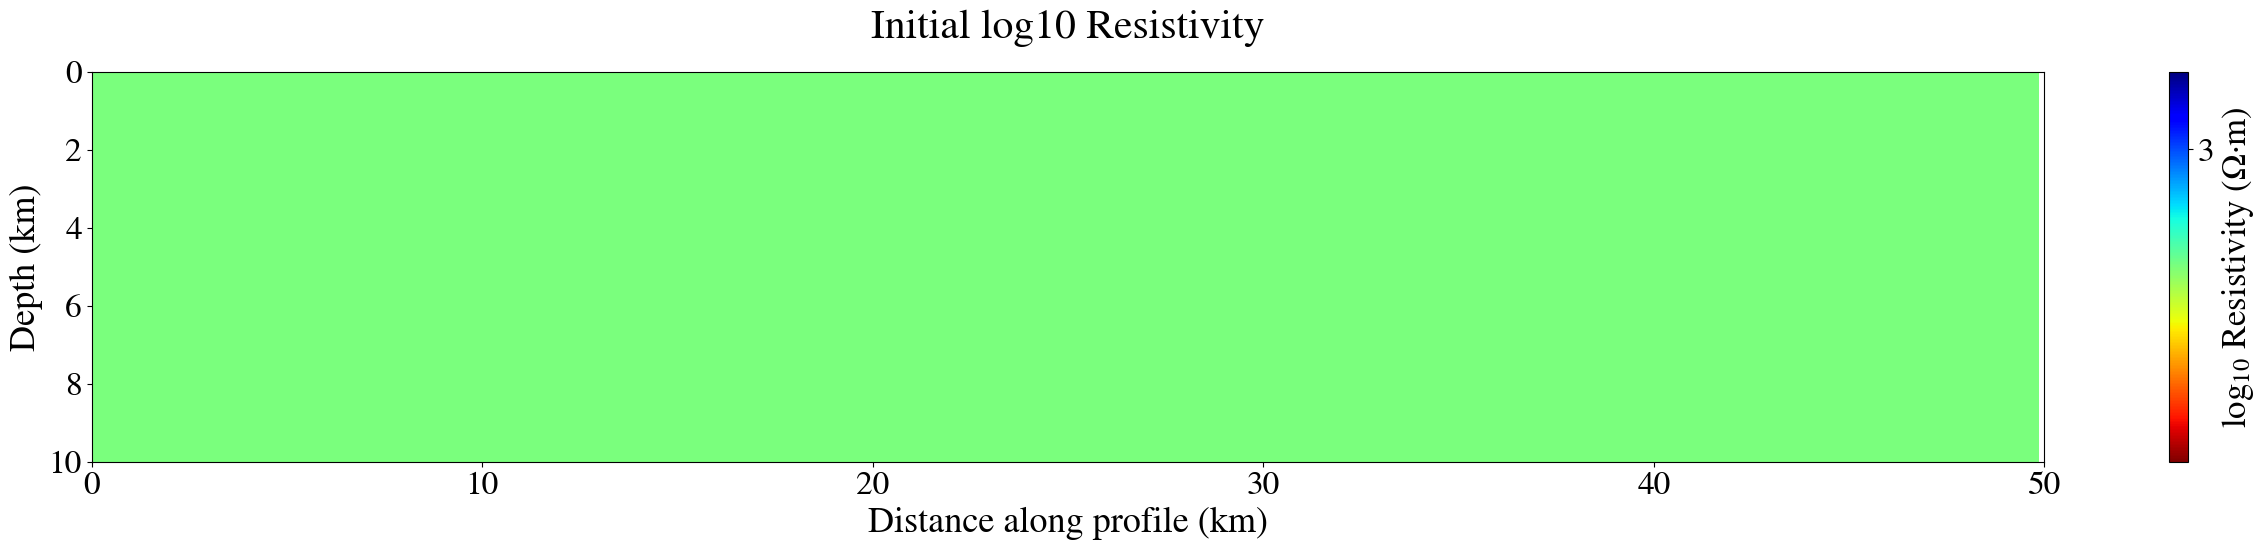

✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0
Epoch 1/300 [   0.3%]
  Elapsed: 0:00:06 | Remaining: ~0:25:50 | ETA: 10:52:28
  Epoch time: 5.19s | Avg: 5.19s
  Total: 1.2906e+02 | Data(6dot): 1.2906e+02
  [Cost weights] w_s=1.000, w_f=1.000, w_d=tensor([[5.0003, 1.0246, 1.0009, 0.4246],
        [5.0003, 0.4391, 1.0009, 1.0238],
        [5.0003, 0.8124, 1.0009, 1.0238],
        ...,
        [5.0003, 1.0246, 1.0009, 1.0238],
        [5.0003, 1.0246, 1.0009, 1.0238],
        [5.0003, 1.0246, 1.0009, 1.0238]], device='cuda:0')
  Misfit(RMS χ²): 22.243 | Rough: 0.00e+00 | Lam: 1.0000000
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e+00 -> 7.63e-02 (ratio=4.009e-02)
Epoch 11/300 [   3.7%]
  Elapsed: 0:01:00 | Remaining: ~0:26:18 | ETA: 10:53:51
  Epoch time: 7.95s | Avg: 5.46s
  Total: 9.4290e+01 | Data(6dot): 9.2928e+01
  Misfit(RMS χ²): 17.212 | Rough: 1.78e+01 | Lam: 0.0762764
  GradNorms: |g_d|=1.824e-02 | |λ·g_m|=1.912e-02
  [Blur anneal] Epoch 11: SMA plat

In [5]:
inv.set_forward_operator()
# 6. 初始化反演模型
# ===============================================
inv.initialize_model(initial_sigma=0.002)
inv.plot_initial_model(
    ylim=[10, 0],
    clip_to_stations=True,
    profile_extend_km=5.0,
    profile_axis_width_km=50.0,
)
# ===============================================
# 7. 运行反演
# ======================================================
final_sigma = inv.run_inversion(
    n_epochs=300,
    mode="6dot",
    progress_interval=10,
    current_lambda=1, #改大会怎样
    use_adaptive_lambda=True,
    lr=0.05,
    update_interval = 20,
    norm_type="L2",
    alpha = 0.8,
    use_depth_weights = True,
    rms_chi2_stop = 1.05,
    enable_blur_anneal=True
)

# ======================================================
# 8. 结果
# ======================================================
print("反演完成，最终模型范围:")
print(final_sigma.min().item(), final_sigma.max().item())

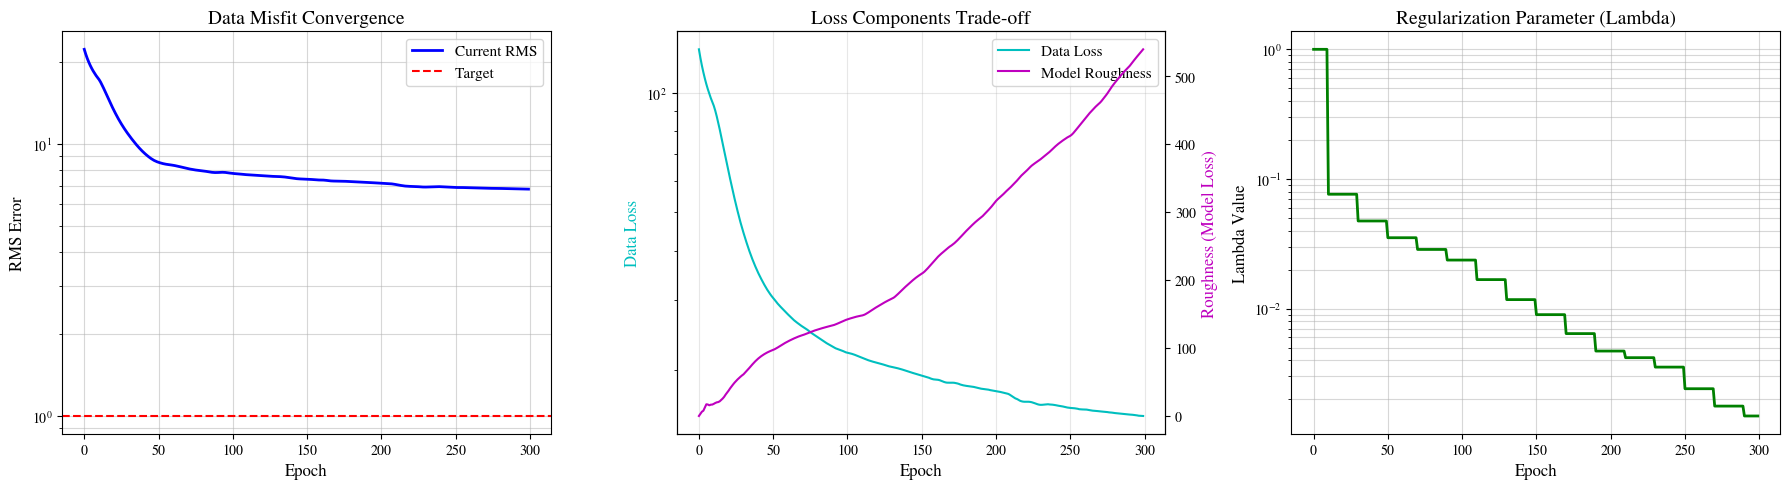

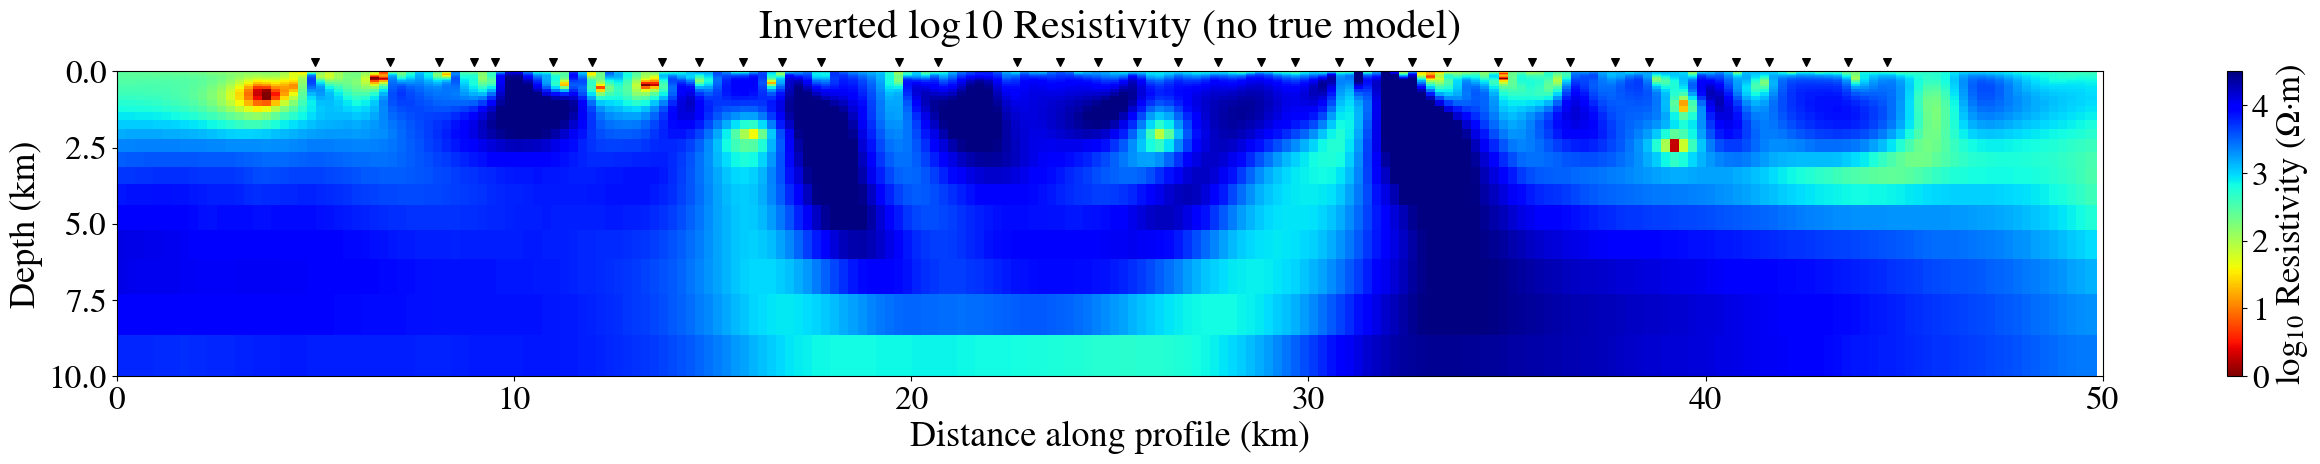

1.18784 902.925


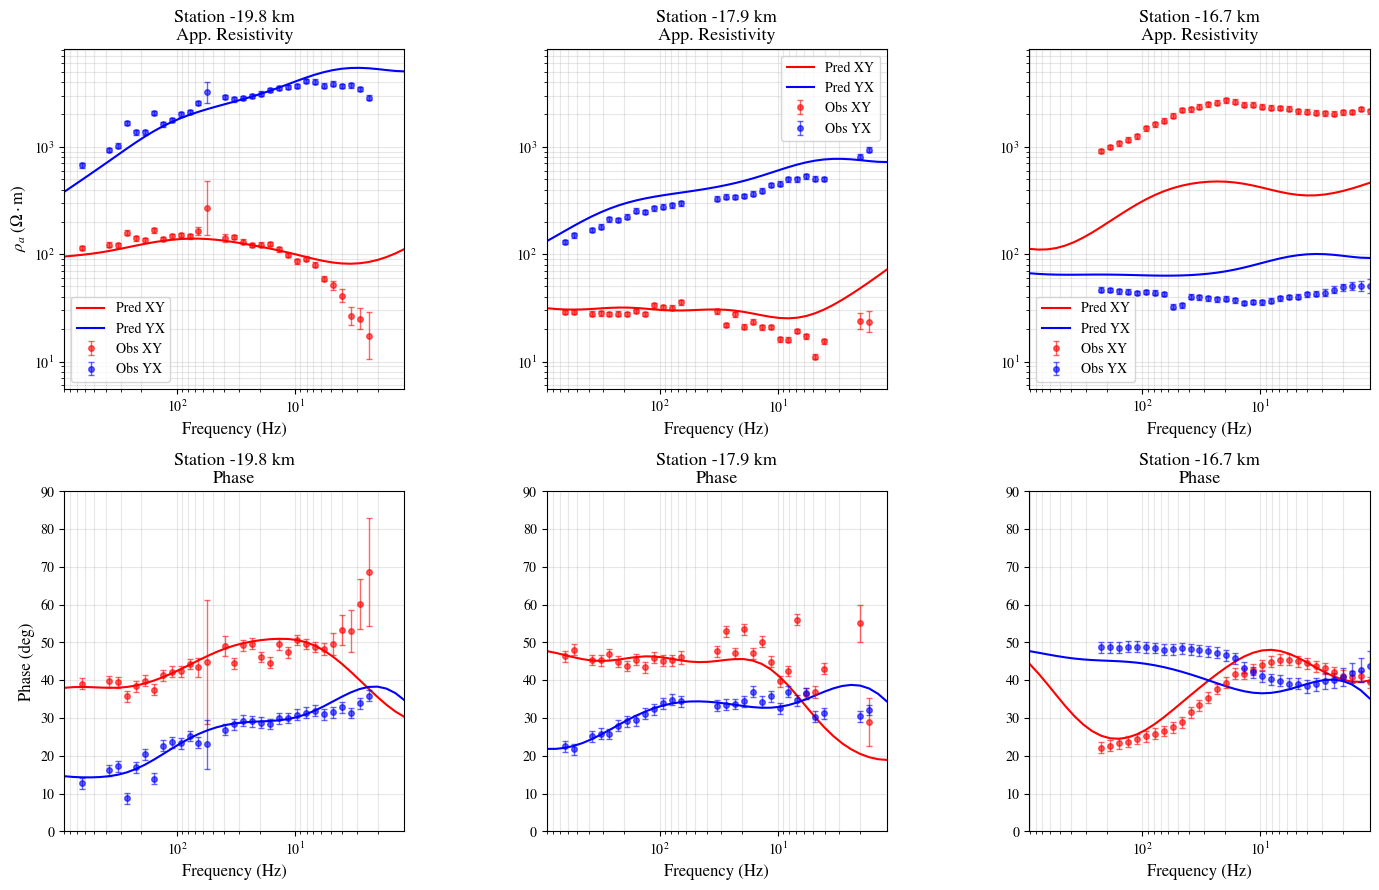

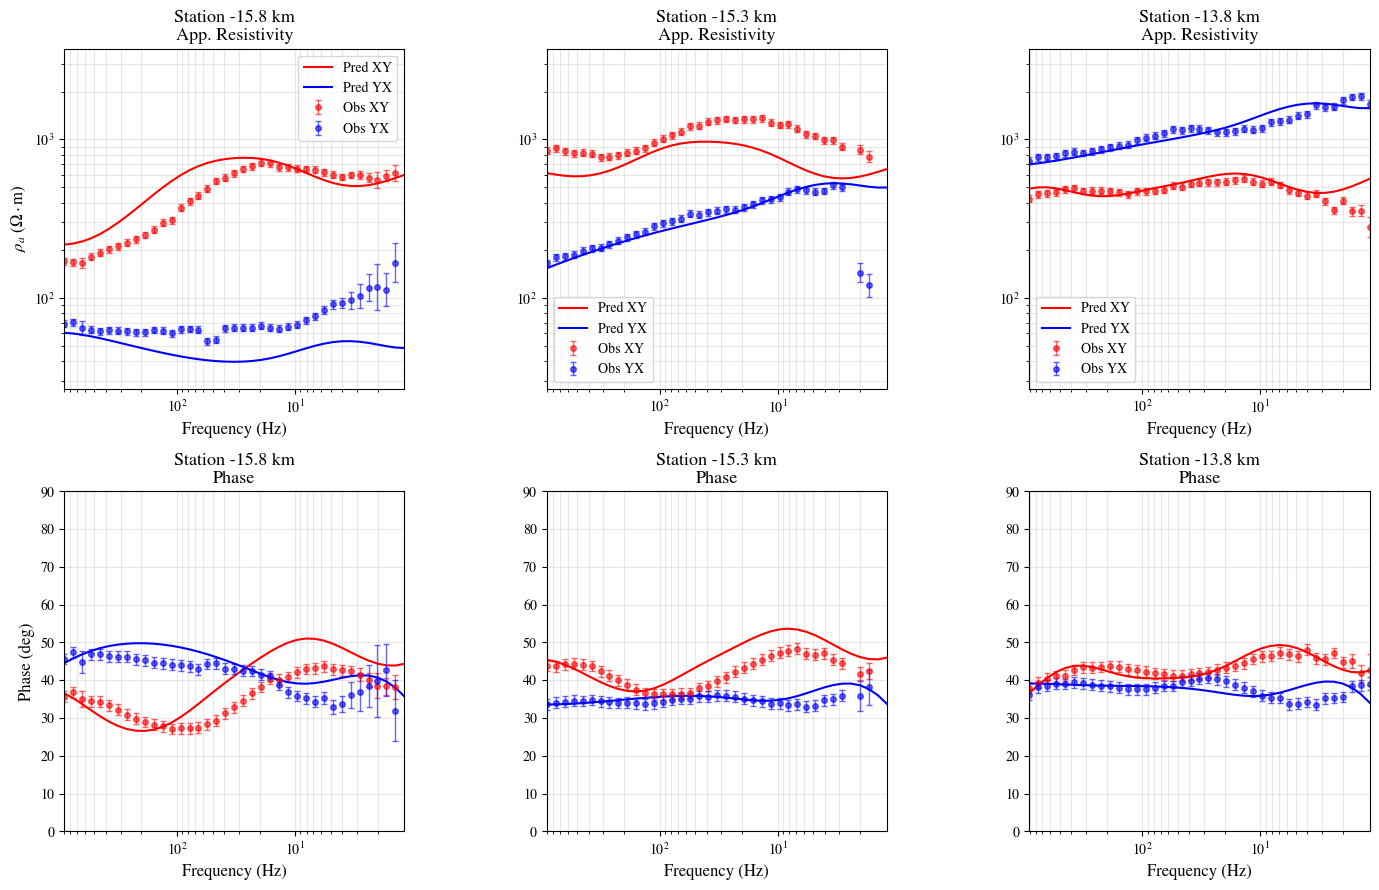

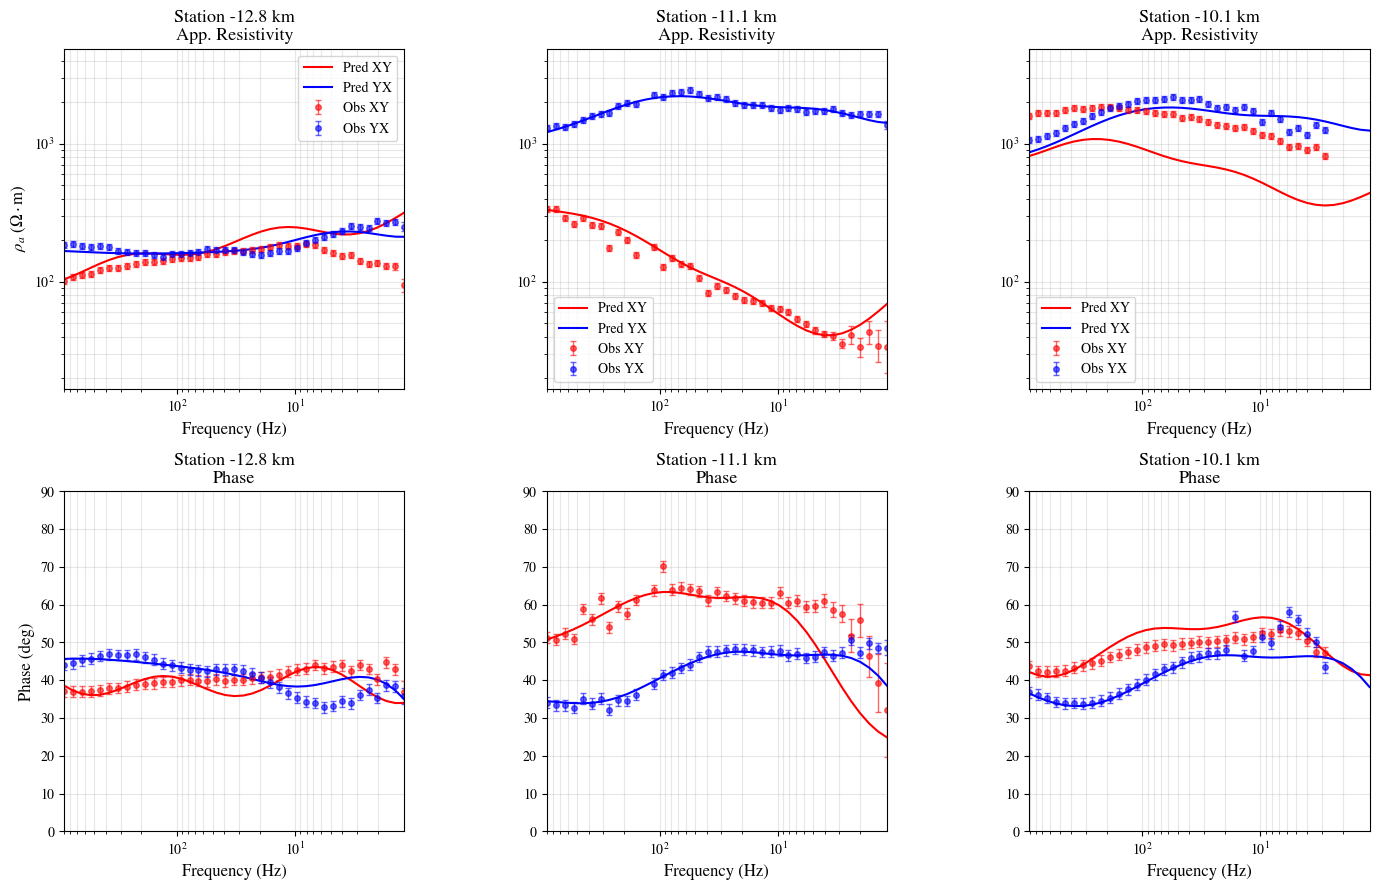

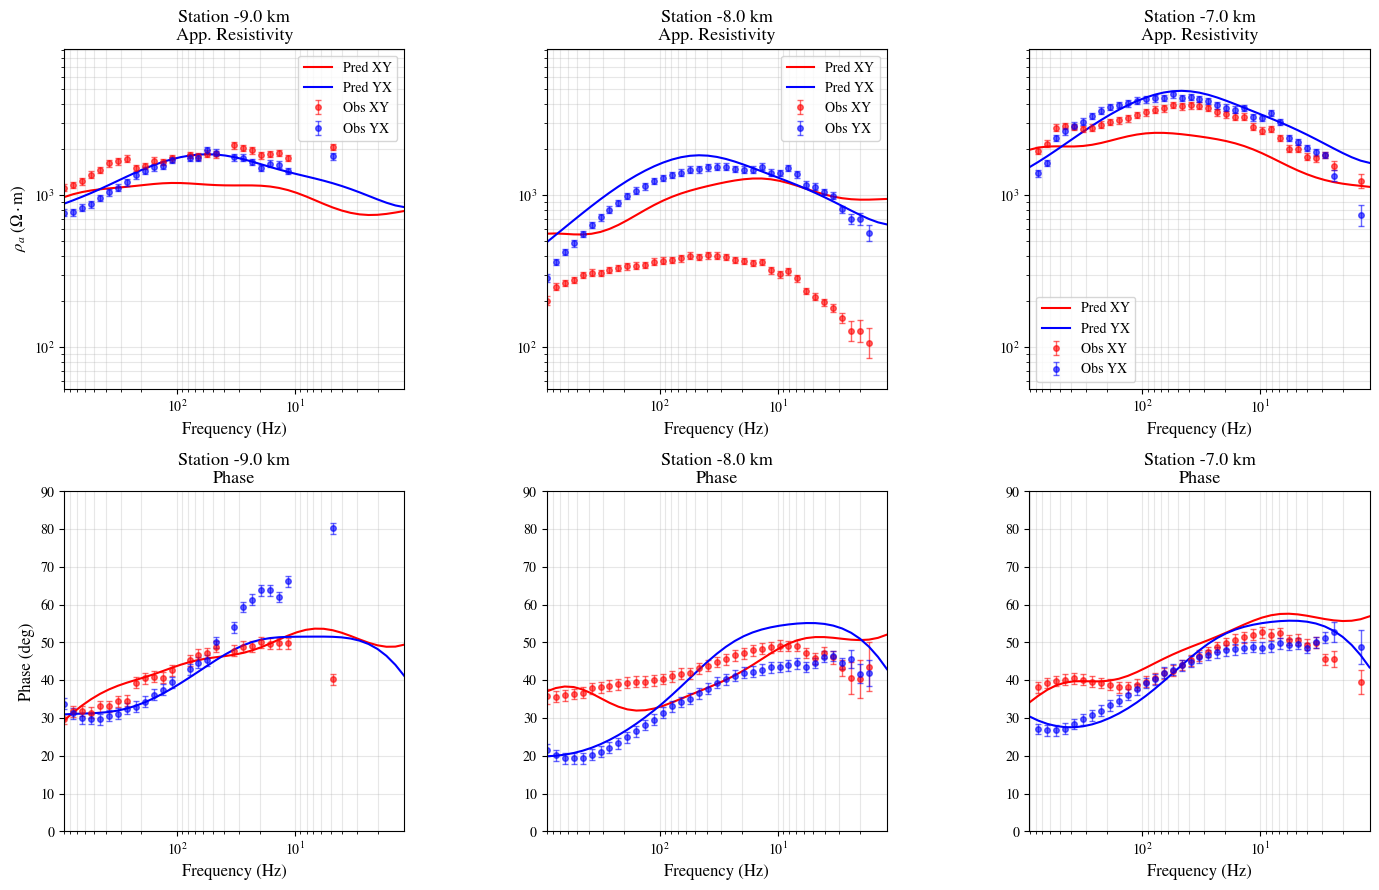

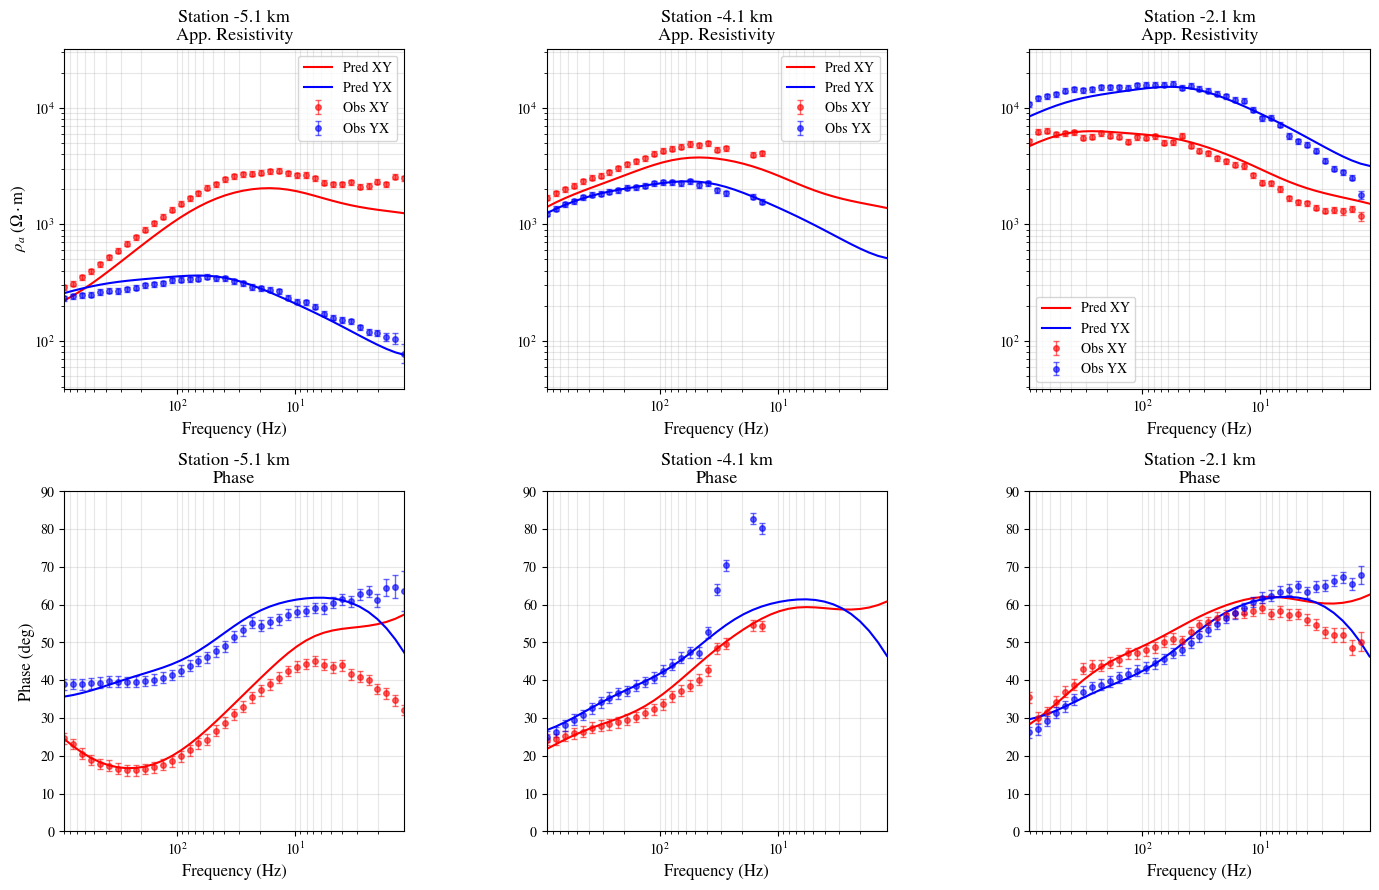

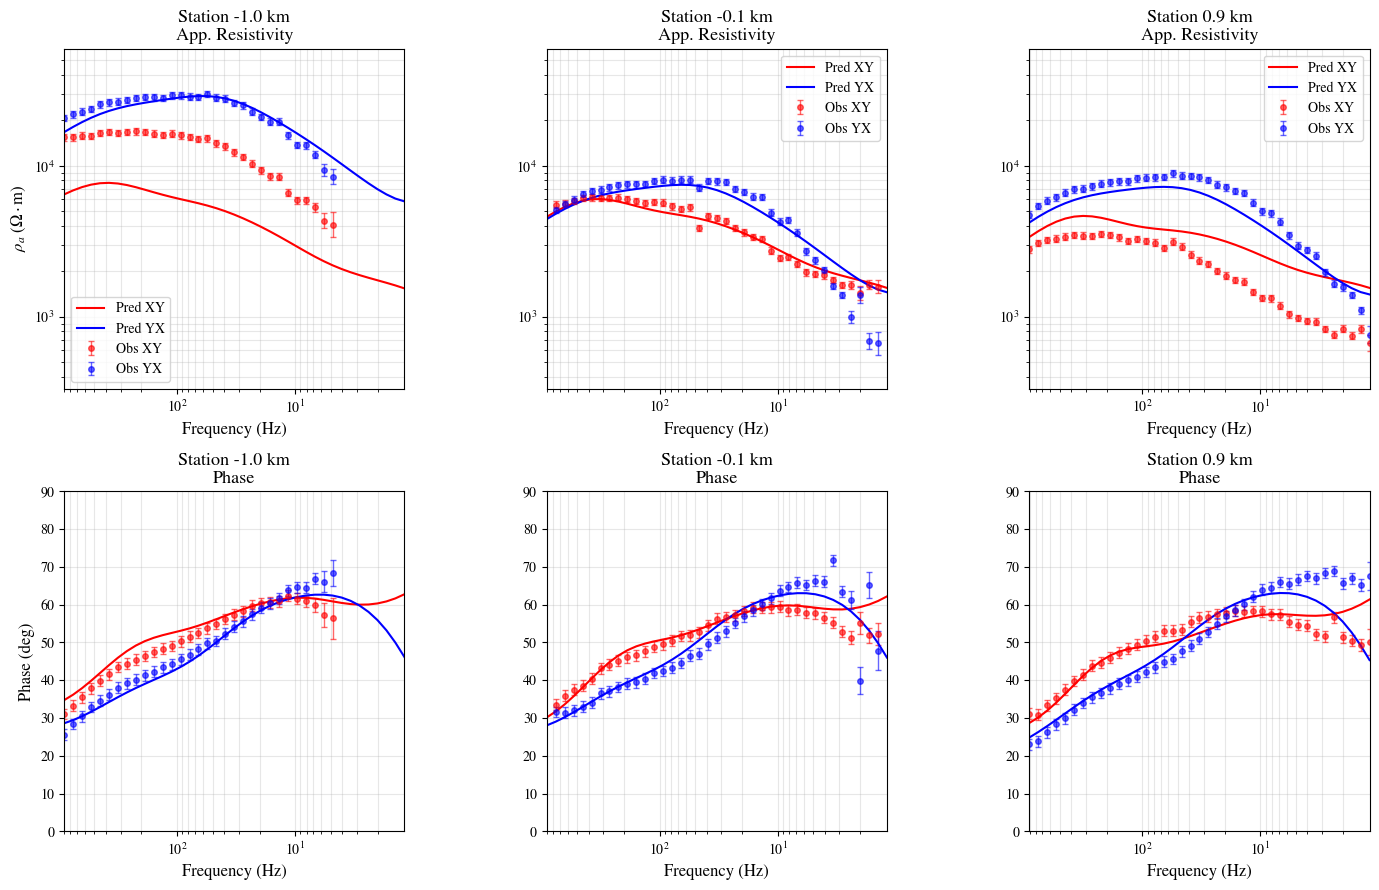

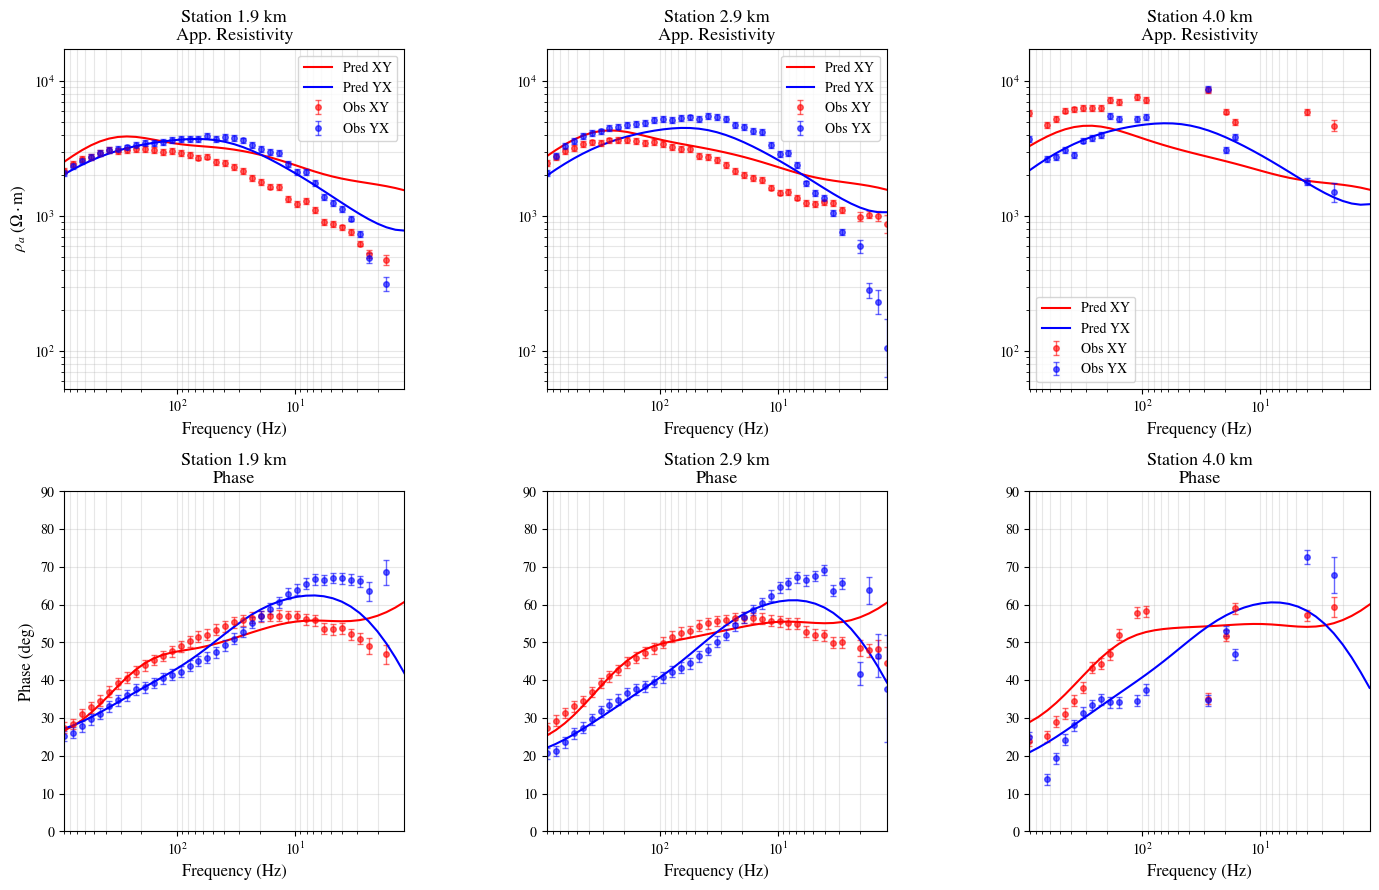

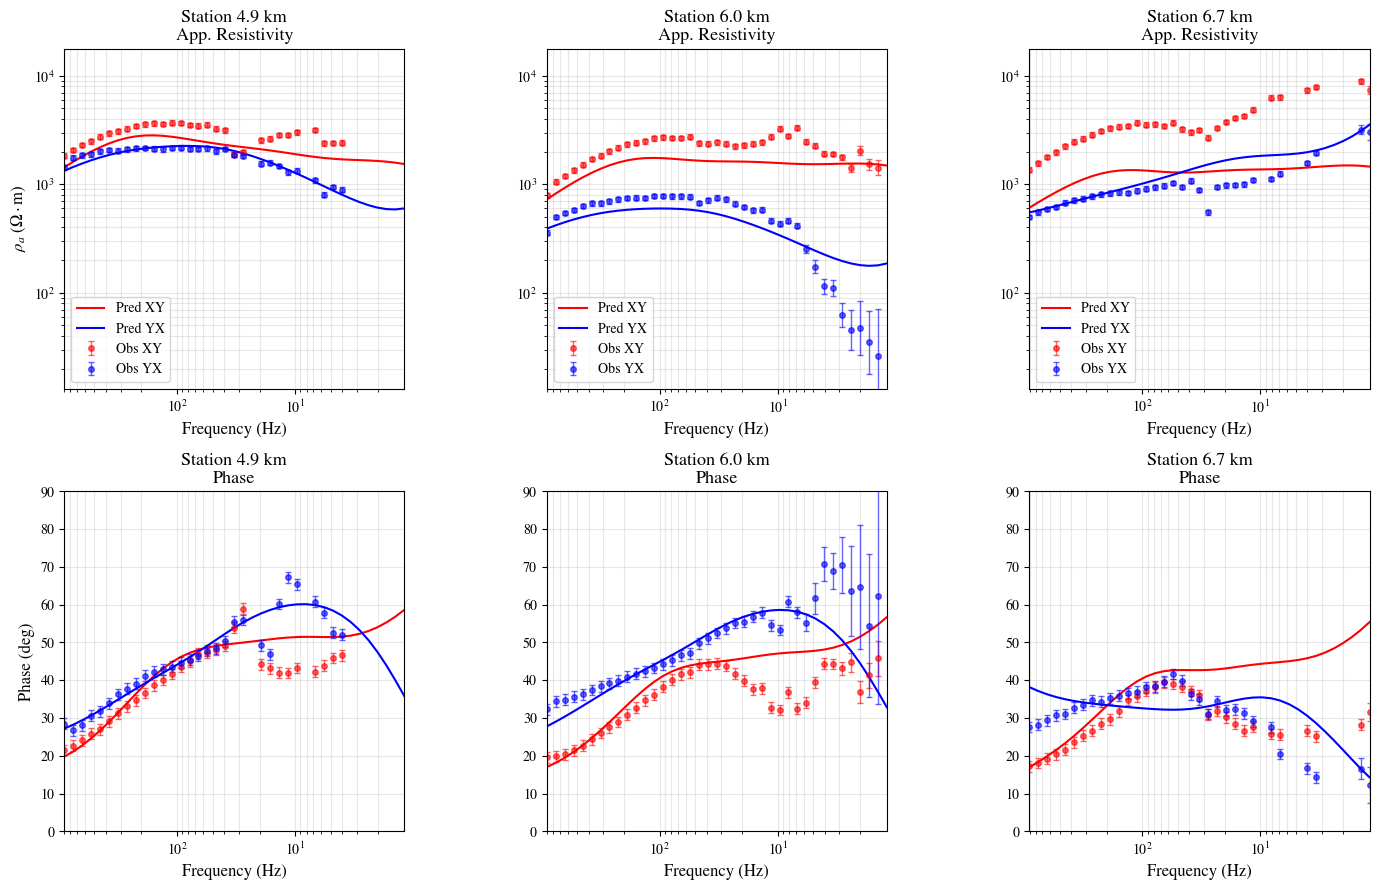

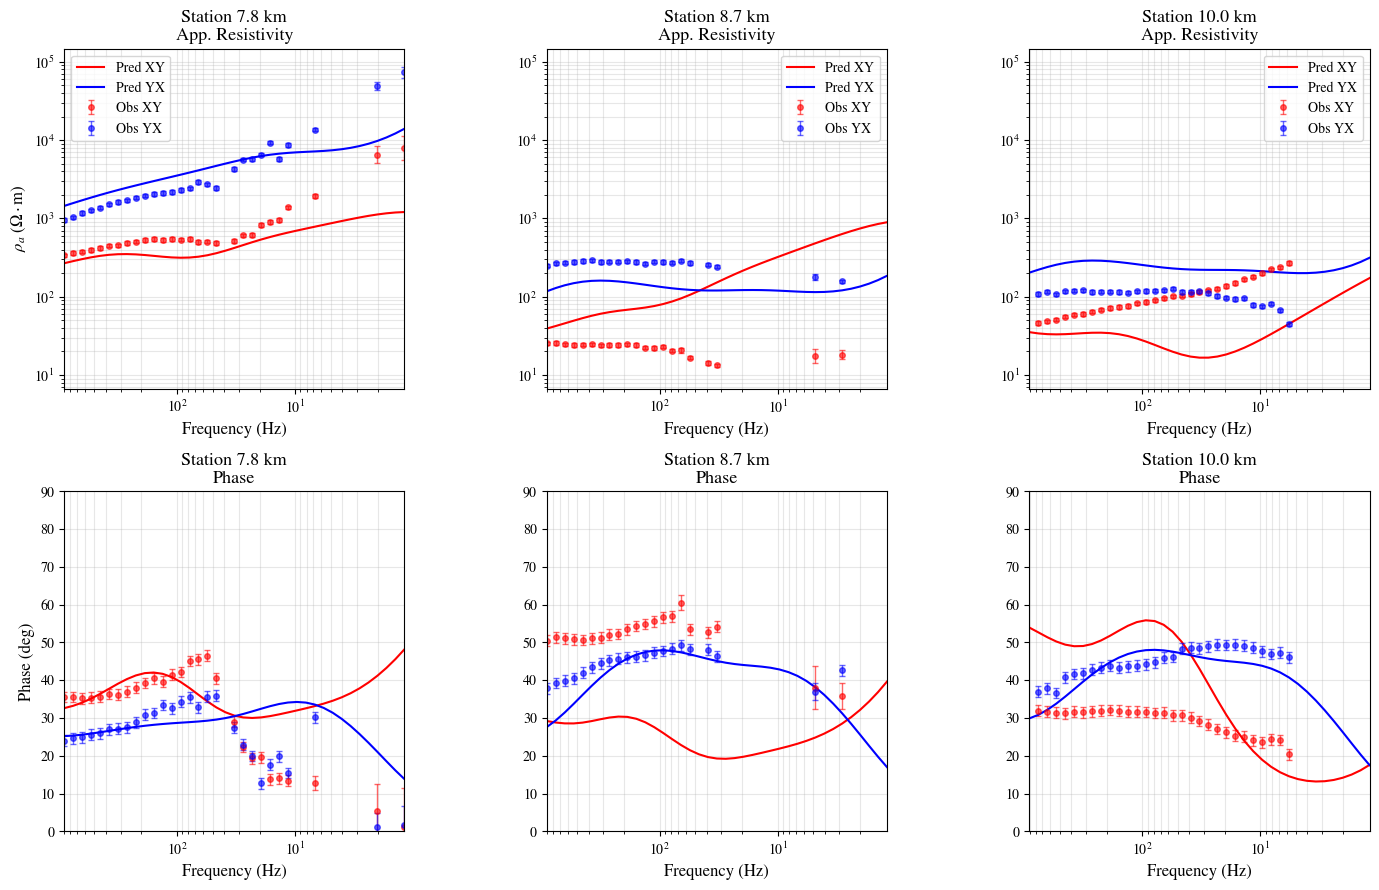

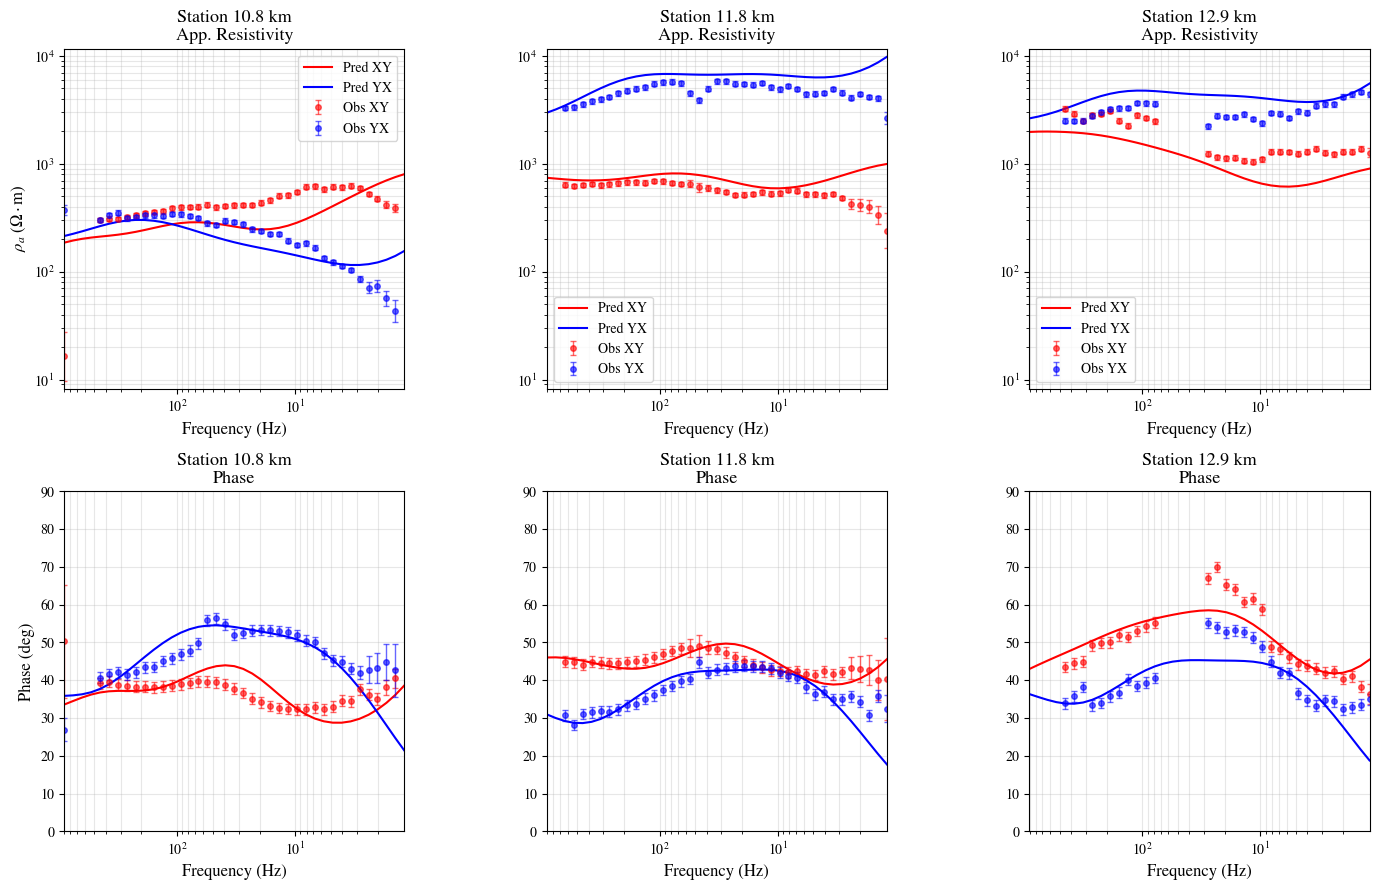

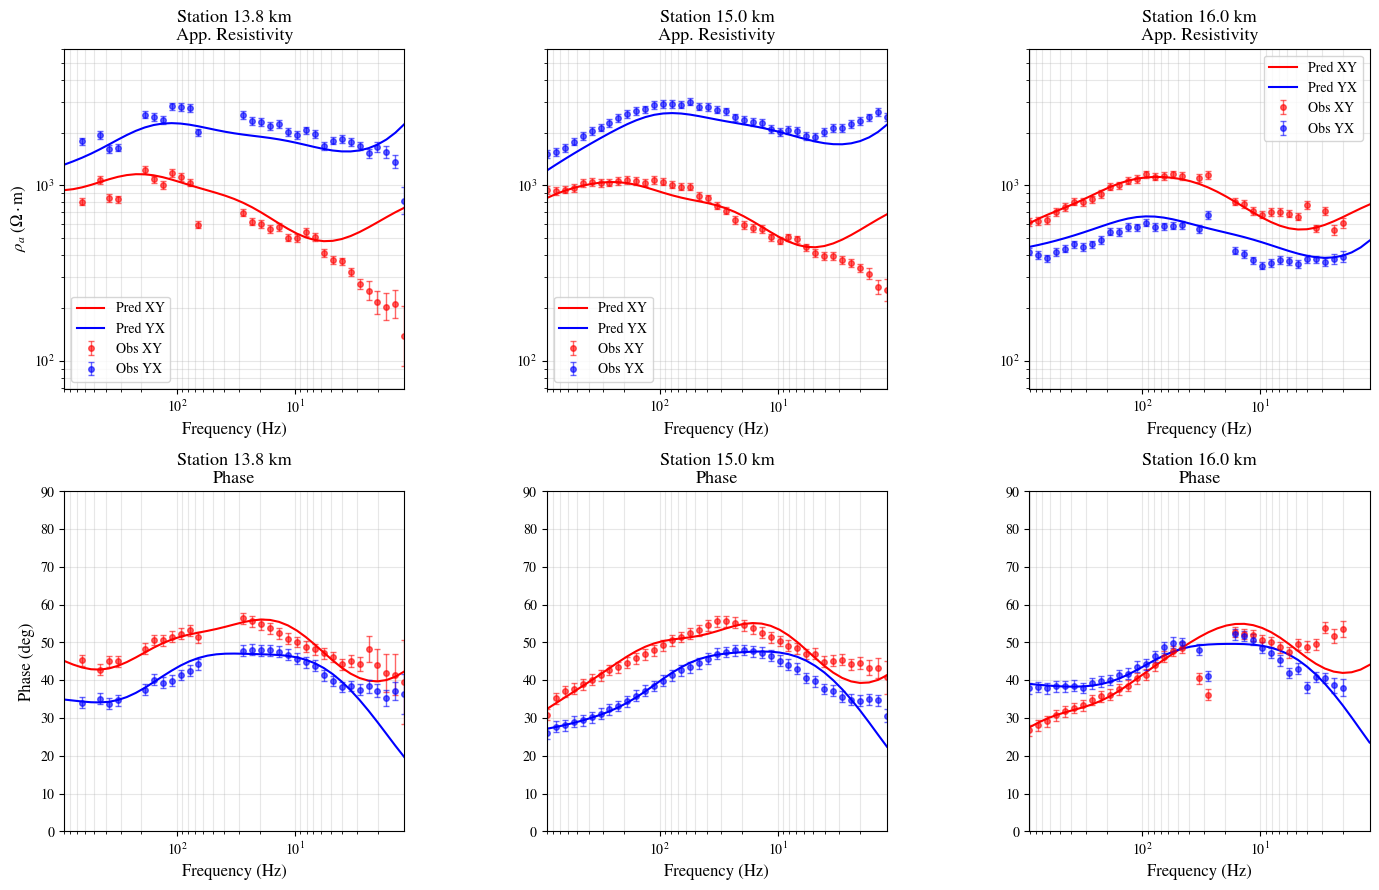

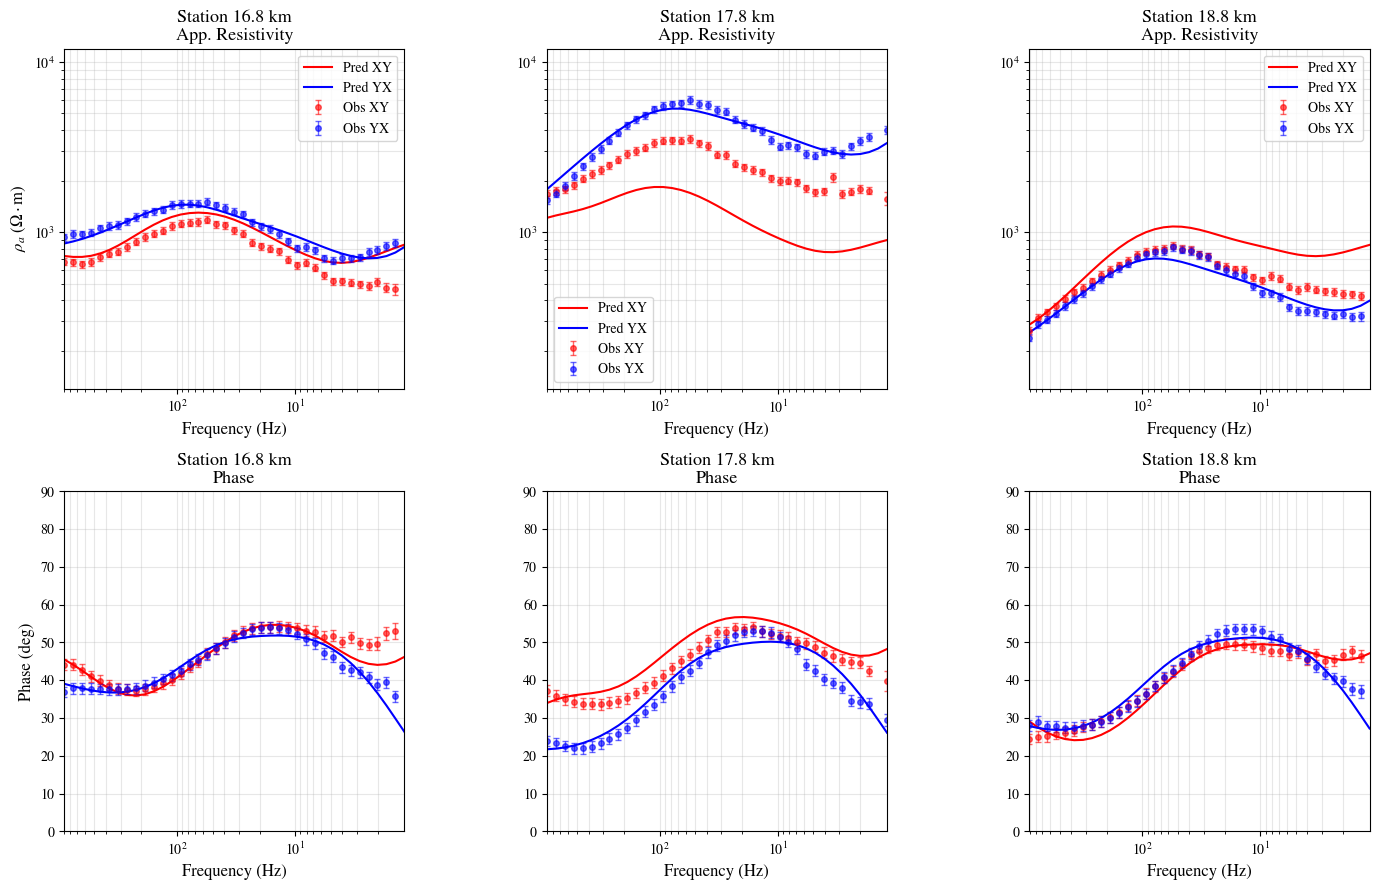

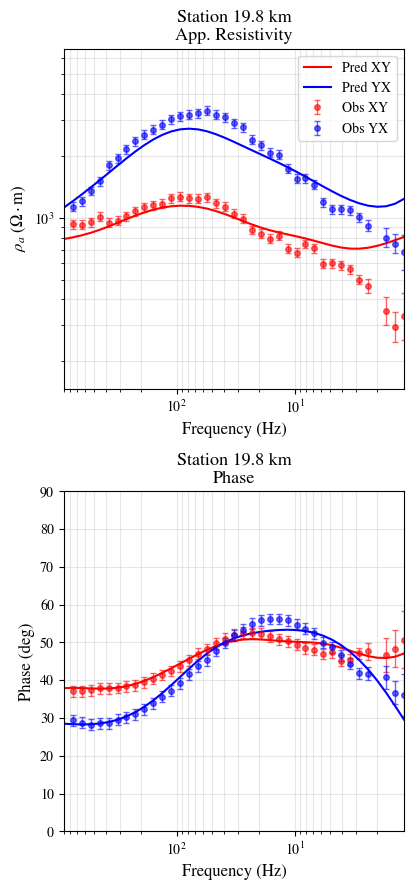

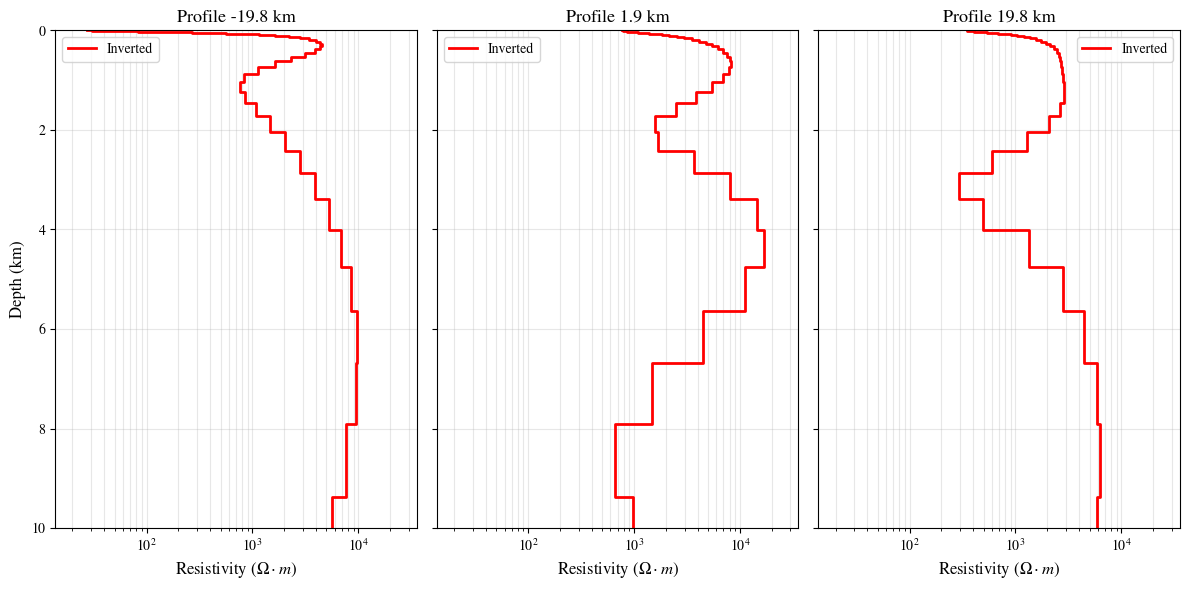

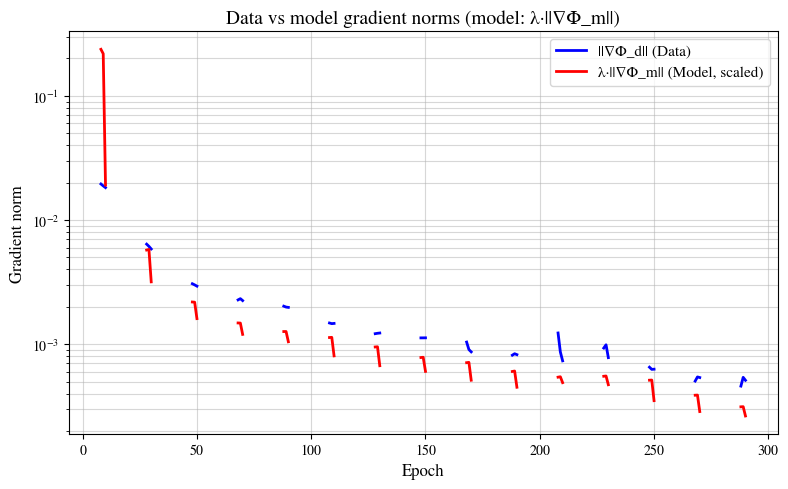

In [6]:
# OT output
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    profile_extend_km=5.0,
    profile_axis_width_km=50.0,
    ylim=[10, 0],
    vmin=0.0, vmax=4.5
)
print(freqs_t.min().item(), freqs_t.max().item())
# Plot data fitting for ALL stations (in batches to keep figures readable)
batch_size = 3  # increase/decrease if you want more/less stations per figure
n_stations = len(inv.stations)
for start in range(0, n_stations, batch_size):
    end = min(start + batch_size, n_stations)
    station_indices = list(range(start, end))
    inv.plot_data_fitting(station_indices=station_indices)
inv.plot_1d_profiles(depth_limit_km=10)
inv.plot_gradient_history()